# <font color='cyan'>APL Logistics — Customer, Product & Profitability Performance Analysis</font>
### Analytical Methodology Notebook

---

**Objective.** APL Logistics has detailed order-level sales data but limited visibility into which customers, products, departments, and markets actually drive profit. This notebook builds that visibility from the ground up — starting from the raw order-item dataset and ending with a set of clearly flagged, data-driven action lists (star products, revenue traps, underperformers, structurally weak departments, over-concentration risks, and repricing/cost/discontinuation candidates).

**Dataset.** 180,519 raw order line items across 118 products, 11 departments, 5 global markets, and 23 order regions, covering 20,649 unique customers.

**Methodology roadmap:**
1. Data Cleaning & Validation
2. Profitability Metric Calculation
3. Product-Level Profitability Analysis
4. Department-Level Performance Analysis
5. Profit Concentration (Pareto Analysis)
6. Cost Diagnostics
7. Visualizations
8. Key Insights & Recommendations

Each stage below states **what** is being computed, **why** it matters, and closes with a short, numbers-grounded interpretation of the actual result.

---

##  <font color='orange'>Step 1 — Data Cleaning & Validation</font>

Before any metric is trusted, the raw dataset needs to be checked for completeness, correctness, and consistent labeling. This step loads the raw file, profiles it for missing values and duplicates, removes invalid records, standardizes text fields, and derives the one field the dataset doesn't provide directly: **Cost**.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('APL_Logistics.csv', encoding='latin1')
print(df.shape)

(180519, 40)


In [3]:
# To view summary of data structure.
df.info()

# Dimensions of Dataframe.
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Fname                 180519 non-null  str    
 12  Customer Id                    180519 non

(180519, 40)

In [4]:
# Statistical summary of all numeric fields - a standard first-pass sanity check
# for implausible values (negative sales, zero quantities, out-of-range rates, etc.)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.980000,7.000000,31.520000,64.800000,911.800000
Sales per customer,180519.0,183.107607,120.043668,7.490000,104.380000,163.990000,247.400000,1939.990000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [5]:
# Used to check missing values in each column of dataset.
df.isnull().sum()[df.isnull().sum() > 0]

Customer Lname      8
Customer Zipcode    3
dtype: int64

In [6]:
# Removing invalid rows (values resulting zero or negative sales).
df = df[df['Sales'] > 0]

# Handling missing customer fields.
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')
df = df.dropna(subset=['Customer Zipcode'])

In [7]:
# Standardizing Labels
df['Department Name'] = df['Department Name'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()
df['Category Name'] = df['Category Name'].str.strip()

In [8]:
# This dataset does not include Order Date / Ship Date fields, so time-based
# margin volatility (as used in the Nassau Candy analysis) is not available here.
# Order Region is used instead as the basis for margin volatility further below.

# Checking for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Deriving implied Cost, since this dataset reports realized profit directly
# rather than a separate unit cost column (Cost = Sales - Order Profit Per Order).
df['Cost'] = df['Sales'] - df['Order Profit Per Order']

print("Clean dataset shape:", df.shape)

Duplicate rows: 0
Clean dataset shape: (180516, 41)


**Interpretation.** The raw file contained 180,519 order line items. Data quality was high: only 8 missing customer last names and 3 missing postal codes (a combined 0.006% of records), no duplicate rows, and no zero/negative sales values. After cleaning, **180,516 clean order line items** remain (99.998% retained) across **118 products**, **11 departments**, **5 markets**, **23 order regions**, and **20,649 customers**. One label — `"Health and Beauty "` — carried a trailing space that `.str.strip()` corrected, which matters because it would otherwise have silently split into two separate groups during department-level aggregation. No records were discarded on data-quality grounds beyond this negligible cleanup — the loss-making transactions surfaced later in this notebook are genuine business outcomes, not artifacts of dirty data.

## <font color='orange'>Step 2 — Profitability Metric Calculation</font>

With clean data in hand, this step builds the core product-level metric table that every later section reuses: **Gross Profit**, **Gross Margin (%)**, **Profit per Unit**, **Total Profit Contribution (%)**, and **Margin Volatility**.

In [9]:
# Group by Product.
product_metrics = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum',
    'Order Item Quantity': 'sum',})

product_metrics = product_metrics.rename(columns={'Order Profit Per Order': 'Gross Profit',
                                                    'Order Item Quantity': 'Units'})

# Gross Margin(%)
product_metrics['Gross Margin (%)'] = (product_metrics['Gross Profit']/
                                   product_metrics['Sales'] * 100).round(2)

# Profit per Unit.
product_metrics['Profit per Unit'] = (product_metrics['Gross Profit']/
                                   product_metrics['Units'])

# Total Profit Contribution
total_profit = product_metrics['Gross Profit'].sum()
product_metrics['Total Profit Contribution (%)'] = ((product_metrics['Gross Profit'] / total_profit) * 100).round(4)

# Display
print(product_metrics)

                                                  Sales  Gross Profit  Units  \
Product Name                                                                   
Adult dog supplies                             41524.80       3589.26    492   
Baby sweater                                   12229.56       1525.03    207   
Bag Boy Beverage Holder                        21116.55       3173.78    845   
Bag Boy M330 Push Cart                         16637.92       2969.11    208   
Bowflex SelectTech 1090 Dumbbells               5999.90       1190.78     10   
...                                                 ...           ...    ...   
adidas Kids' F5 Messi FG Soccer Cleat          27327.19       2906.33    781   
adidas Men's F10 Messi TRX FG Soccer Cleat     56330.61       8213.07    939   
adidas Men's Germany Black Crest Away Tee      21475.00       2833.72    859   
adidas Youth Germany Black/Red Away Match Soc  67830.00       8129.40    969   
insta-bed Neverflat Air Mattress        

In [10]:
# Margin Volatility (KPI 5): variability of margin per product across order regions
# (substituted for time-based volatility, since no order date field exists in this dataset)

# Regional margin per product
regional_margin = df.groupby(['Product Name', 'Order Region']).apply(
    lambda g: (g['Order Profit Per Order'].sum() / g['Sales'].sum()) * 100
).reset_index(name='Regional Margin (%)')

# Std deviation of regional margin = volatility
margin_volatility = regional_margin.groupby('Product Name')['Regional Margin (%)'].std().round(2)
margin_volatility = margin_volatility.rename('Margin Volatility')

# Merge into product_metrics
product_metrics = product_metrics.merge(margin_volatility, left_index=True, right_index=True, how='left')
product_metrics['Margin Volatility'] = product_metrics['Margin Volatility'].fillna(0)

print(product_metrics[['Gross Margin (%)', 'Margin Volatility']])

                                               Gross Margin (%)  \
Product Name                                                      
Adult dog supplies                                         8.64   
Baby sweater                                              12.47   
Bag Boy Beverage Holder                                   15.03   
Bag Boy M330 Push Cart                                    17.85   
Bowflex SelectTech 1090 Dumbbells                         19.85   
...                                                         ...   
adidas Kids' F5 Messi FG Soccer Cleat                     10.64   
adidas Men's F10 Messi TRX FG Soccer Cleat                14.58   
adidas Men's Germany Black Crest Away Tee                 13.20   
adidas Youth Germany Black/Red Away Match Soc             11.98   
insta-bed Neverflat Air Mattress                          11.52   

                                               Margin Volatility  
Product Name                                                 

In [11]:
# Quick portfolio-level snapshot before drilling into individual products
print(f"Company-wide Gross Margin: {(product_metrics['Gross Profit'].sum() / product_metrics['Sales'].sum() * 100):.2f}%")
print(f"Median product margin: {product_metrics['Gross Margin (%)'].median():.2f}%")
print(f"Highest margin volatility: {product_metrics['Margin Volatility'].idxmax()} "
      f"({product_metrics['Margin Volatility'].max():.2f} pts across regions)")
print(f"Lowest margin volatility: {product_metrics['Margin Volatility'].idxmin()} "
      f"({product_metrics['Margin Volatility'].min():.2f} pts across regions)")
print(f"Products with negative total profit: {(product_metrics['Gross Profit'] < 0).sum()}")

Company-wide Gross Margin: 10.78%
Median product margin: 11.00%
Highest margin volatility: Nike Men's Free TR 5.0 TB Training Shoe (68.11 pts across regions)
Lowest margin volatility: Bushnell Pro X7 Jolt Slope Rangefinder (0.00 pts across regions)
Products with negative total profit: 3


**Interpretation.** The blended company-wide margin is **10.78%**, and individual product margins cluster fairly tightly around that figure — but not uniformly. Only **3 of 118 products** (Bushnell Pro X7 Jolt Slope Rangefinder, SOLE E25 Elliptical, SOLE E35 Elliptical) are net loss-making across their full sales history, which is reassuring: the business is not carrying a large hidden pool of structurally unprofitable SKUs. Margin volatility — how much a product's margin swings across order regions — varies meaningfully by product, flagging which items are consistently priced/costed versus which behave differently depending on where they're sold.

## <font color='orange'>Step 3 — Product-Level Profitability Analysis</font>

This step ranks and segments all 118 products into three actionable groups using simple median-split logic: **Star Products** (above-median profit AND above-median margin), **Revenue Traps** (above-median sales but below-median margin), and **Underperformers** (below-median sales AND below-median profit).

In [12]:
# Ranking products by : Gross Profit
Gross_Profit_Rank = product_metrics.sort_values(by='Gross Profit',
                                                ascending=False)

print(Gross_Profit_Rank)

                                                    Sales  Gross Profit  \
Product Name                                                              
Field & Stream Sportsman 16 Gun Fire Safe      6929653.50     756220.76   
Perfect Fitness Perfect Rip Deck               4421143.02     493828.30   
Diamondback Women's Serene Classic Comfort Bi  4118425.42     427455.57   
Nike Men's Free 5.0+ Running Shoe              3667633.20     379915.82   
Nike Men's Dri-FIT Victory Golf Polo           3147800.00     350421.03   
...                                                   ...           ...   
Diamondback Girls' Clarity 24 Hybrid Bike 201     8399.72        284.42   
GoPro HERO3+ Black Edition Camera                12799.68        245.63   
SOLE E25 Elliptical                               9999.90       -169.56   
Bushnell Pro X7 Jolt Slope Rangefinder            6599.89       -255.95   
SOLE E35 Elliptical                              29999.85       -965.12   

                        

In [13]:
# Ranking products by : Gross Margin(%)
Gross_Margin_Rank = product_metrics.sort_values(by='Gross Margin (%)',
                                                ascending=False)

print(Gross_Margin_Rank)

                                                  Sales  Gross Profit  Units  \
Product Name                                                                   
Diamondback Boys' Insight 24 Performance Hybr   8699.71       1730.81     29   
Bowflex SelectTech 1090 Dumbbells               5999.90       1190.78     10   
Polar FT4 Heart Rate Monitor                   17638.04       3476.85    196   
Elevation Training Mask 2.0                    18477.69       3299.57    231   
Bag Boy M330 Push Cart                         16637.92       2969.11    208   
...                                                 ...           ...    ...   
Garmin Forerunner 910XT GPS Watch              13999.65        391.13     35   
GoPro HERO3+ Black Edition Camera              12799.68        245.63     32   
SOLE E25 Elliptical                             9999.90       -169.56     10   
SOLE E35 Elliptical                            29999.85       -965.12     15   
Bushnell Pro X7 Jolt Slope Rangefinder  

In [14]:
# Lets consider High-profit / High-Margin Products as Star_Products
Star_Products = product_metrics[(product_metrics['Gross Profit'] >
                                 product_metrics['Gross Profit'].median()) &
                                (product_metrics['Gross Margin (%)'] >
                                 product_metrics['Gross Margin (%)'].median())]

print(f"Star Products: {len(Star_Products)} of {len(product_metrics)}\n")
print(Star_Products)

Star Products: 36 of 118

                                                    Sales  Gross Profit  \
Product Name                                                              
Bag Boy Beverage Holder                          21116.55       3173.78   
Bag Boy M330 Push Cart                           16637.92       2969.11   
Brooks Women's Ghost 6 Running Shoe              19077.88       2606.85   
Children's heaters                              232472.10      27118.11   
Elevation Training Mask 2.0                      18477.69       3299.57   
Garmin Approach S3 Golf GPS Watch                19249.23       2432.33   
Glove It Women's Mod Oval Golf Glove             16031.98       2406.57   
Industrial consumer electronics                 108738.40      13157.02   
LIJA Women's Mid-Length Panel Golf Shorts        22700.00       2984.71   
Lawn mower                                      257768.72      33443.01   
Nike Men's Comfort 2 Slide                       44585.09       5747.98   

In [15]:
# High-Sales / Low-Margin Products as Revenue_Traps
Revenue_Traps = product_metrics[(product_metrics['Sales'] >
                                 product_metrics['Sales'].median()) &
                                (product_metrics['Gross Margin (%)'] <
                                 product_metrics['Gross Margin (%)'].median())]

print(f"Revenue Traps: {len(Revenue_Traps)} of {len(product_metrics)}\n")
print(Revenue_Traps)

Revenue Traps: 32 of 118

                                                    Sales  Gross Profit  \
Product Name                                                              
Adult dog supplies                               41524.80       3589.26   
Bridgestone e6 Straight Distance NFL Carolina    29686.72       3188.77   
Bridgestone e6 Straight Distance NFL San Dieg    28982.94       2019.83   
Bridgestone e6 Straight Distance NFL Tennesse    25751.95       2361.75   
Clicgear Rovic Cooler Bag                        34671.33       2962.96   
Columbia Men's PFG Anchor Tough T-Shirt          27840.00       2454.80   
DVDs                                             79395.54       6655.43   
Dell Laptop                                     663000.00      69656.81   
Diamondback Women's Serene Classic Comfort Bi  4118425.42     427455.57   
ENO Atlas Hammock Straps                         29930.02       2139.58   
Field & Stream Sportsman 16 Gun Fire Safe      6929653.50     756220.76   

In [16]:
# Low-Sales / Low-Profit Products as Underperformers
Underperformers = product_metrics[(product_metrics['Sales'] <
                                 product_metrics['Sales'].median()) &
                                (product_metrics['Gross Profit'] <
                                 product_metrics['Gross Profit'].median())]

print(f"Underperformers: {len(Underperformers)} of {len(product_metrics)}\n")
print(Underperformers)

Underperformers: 49 of 118

                                                  Sales  Gross Profit  Units  \
Product Name                                                                   
Baby sweater                                   12229.56       1525.03    207   
Bowflex SelectTech 1090 Dumbbells               5999.90       1190.78     10   
Bushnell Pro X7 Jolt Slope Rangefinder          6599.89       -255.95     11   
CDs of rock                                     3059.59        383.85    271   
Cleveland Golf Collegiate My Custom Wedge 588  13649.35        955.10     65   
Cleveland Golf Women's 588 RTX CB Satin Chrom   8399.30        370.61     70   
Clicgear 8.0 Shoe Brush                         8871.12        815.54    888   
Diamondback Boys' Insight 24 Performance Hybr   8699.71       1730.81     29   
Diamondback Girls' Clarity 24 Hybrid Bike 201   8399.72        284.42     28   
Fitbit The One Wireless Activity & Sleep Trac  18690.65       2088.02    187   
Garmin Appro

**Interpretation.** The catalog splits into **36 Star Products**, **32 Revenue Traps**, and **49 Underperformers** (groups can overlap slightly at the median boundary). The Star Products list is led by high-volume names like *Nike Men's Dri-FIT Victory Golf Polo* and *O'Brien Men's Neoprene Life Vest* — these combine scale and margin and are the products to protect and promote. The Revenue Traps group is the more urgent one commercially: it includes some of the company's single largest revenue lines — *Field & Stream Sportsman 16 Gun Fire Safe* ($6.93M in sales) and *Diamondback Women's Serene Classic Comfort Bike* ($4.12M) — meaning a large share of total revenue is running through products whose margin sits below the catalog median. Even a small margin improvement on this group would move the needle on total company profit more than the same improvement applied to a low-volume product.

## <font color='orange'>Step 4 — Department-Level Performance Analysis</font>

Zooming out from individual products to the 11 department-level business groupings (the closest structural equivalent to Nassau Candy's *Division* field), this step checks whether revenue share and profit share move together — and flags departments where they don't.

In [17]:
# Aggregate Metrics by Department
# (Department Name is the closest structural equivalent to Nassau's Division field
# - a small set of top-level business groupings, 11 departments in this dataset)
department_metrics = df.groupby('Department Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum',
    'Order Item Quantity': 'sum'
})

department_metrics = department_metrics.rename(columns={'Order Profit Per Order': 'Gross Profit',
                                                          'Order Item Quantity': 'Units'})

# Average margin by department.
department_metrics['Average Margin (%)'] = ((
    department_metrics['Gross Profit'] /
    department_metrics['Sales']
) * 100).round(2)

print(department_metrics.sort_values('Gross Profit', ascending=False))

                         Sales  Gross Profit   Units  Average Margin (%)
Department Name                                                         
Fan Shop           17113870.54    1834155.43  106165               10.72
Apparel             7975897.98     881822.94   98180               11.06
Golf                4609028.22     497523.56   99297               10.79
Footwear            4006498.77     410222.50   43400               10.24
Outdoors            1253351.44     145251.46   26059               11.59
Technology          1039346.08     113103.63    1464               10.88
Fitness              397050.89      46538.06    6227               11.72
Discs Shop           228847.98      24182.21    2025               10.57
Health and Beauty    106080.48       9493.63     362                8.95
Pet Shop              41524.80       3589.26     492                8.64
Book Shop             12587.40        883.01     405                7.02


In [18]:
# Revenue vs Profit Imbalance.
total_sales = department_metrics['Sales'].sum()
total_profit = department_metrics['Gross Profit'].sum()

department_metrics['Revenue Contribution (%)'] = (
    department_metrics['Sales'] / total_sales
) * 100

department_metrics['Profit Contribution (%)'] = (
    department_metrics['Gross Profit'] / total_profit
) * 100

print(department_metrics[['Revenue Contribution (%)', 'Profit Contribution (%)', 'Average Margin (%)']]
      .sort_values('Revenue Contribution (%)', ascending=False))

                   Revenue Contribution (%)  Profit Contribution (%)  \
Department Name                                                        
Fan Shop                          46.525204                46.238058   
Apparel                           21.683013                22.230275   
Golf                              12.529952                12.542298   
Footwear                          10.891936                10.341486   
Outdoors                           3.407320                 3.661710   
Technology                         2.825532                 2.851281   
Fitness                            1.079409                 1.173199   
Discs Shop                         0.622139                 0.609620   
Health and Beauty                  0.288387                 0.239329   
Pet Shop                           0.112888                 0.090483   
Book Shop                          0.034220                 0.022260   

                   Average Margin (%)  
Department Name        

In [19]:
# Strong Financial Efficiency
strong_efficiency = department_metrics[
    (department_metrics['Average Margin (%)'] > department_metrics['Average Margin (%)'].median()) &
    (department_metrics['Profit Contribution (%)'] > department_metrics['Profit Contribution (%)'].median())
]

print(strong_efficiency)

                      Sales  Gross Profit  Units  Average Margin (%)  \
Department Name                                                        
Apparel          7975897.98     881822.94  98180               11.06   
Golf             4609028.22     497523.56  99297               10.79   
Outdoors         1253351.44     145251.46  26059               11.59   

                 Revenue Contribution (%)  Profit Contribution (%)  
Department Name                                                     
Apparel                         21.683013                22.230275  
Golf                            12.529952                12.542298  
Outdoors                         3.407320                 3.661710  


In [20]:
# Structural Margin Issues
# AND condition - flags departments that generate a meaningful share of revenue
# but underperform on margin (rather than OR, which would over-flag almost every department).
margin_issues = department_metrics[
    (department_metrics['Revenue Contribution (%)'] >= department_metrics['Revenue Contribution (%)'].median()) &
    (department_metrics['Average Margin (%)'] < department_metrics['Average Margin (%)'].median())
]
print(margin_issues)

                      Sales  Gross Profit  Units  Average Margin (%)  \
Department Name                                                        
Footwear         4006498.77      410222.5  43400               10.24   

                 Revenue Contribution (%)  Profit Contribution (%)  
Department Name                                                     
Footwear                        10.891936                10.341486  


**Interpretation.** **Fan Shop** ($17.1M sales, $1.83M profit) and **Apparel** ($7.98M sales, $0.88M profit) are the two largest departments by revenue, and both convert that scale into above-median margin (10.72% and 11.06% respectively) — a healthy sign that the biggest departments aren't the weakest ones. **Apparel, Golf, and Outdoors** stand out as *Strong Financial Efficiency* departments, contributing more to profit than to revenue proportionally. The one department flagged under *Structural Margin Issues* is **Footwear** — it holds an above-median 10.89% revenue share but only a 10.24% average margin, the lowest among all departments carrying meaningful volume. This makes Footwear the department most worth investigating for supplier cost or pricing structure.

## <font color='orange'>Step 5 — Profit Concentration (Pareto Analysis)</font>

This step tests the classic 80/20 rule at three levels — product, market, and order region — to see how concentrated APL Logistics' revenue and profit really are, and to quantify the resulting dependency risk.

In [21]:
# Product-Level Aggregation
pareto = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

pareto = pareto.rename(columns={'Order Profit Per Order': 'Gross Profit'})

In [22]:
# [[Products Contributing to 80% Revenue]] :
 # 1.Sort by Sales
revenue_pareto = pareto.sort_values(
    by='Sales',
    ascending=False)


 # 2.Cumulative Revenue (%)
revenue_pareto['Cumulative Revenue (%)'] = ((
    revenue_pareto['Sales'].cumsum() /
    revenue_pareto['Sales'].sum()
) * 100).round(2)
print(revenue_pareto)


# Overall Products Contributing to 80% Revenue
top_80_revenue = revenue_pareto[
    revenue_pareto['Cumulative Revenue (%)'] <= 80]
print(f"\nProducts needed to reach 80% of revenue: {len(top_80_revenue)} of {len(pareto)} ({len(top_80_revenue)/len(pareto)*100:.1f}% of the catalog)")
print(top_80_revenue)

                                      Product Name       Sales  Gross Profit  \
24       Field & Stream Sportsman 16 Gun Fire Safe  6929653.50     756220.76   
71                Perfect Fitness Perfect Rip Deck  4421143.02     493828.30   
21   Diamondback Women's Serene Classic Comfort Bi  4118425.42     427455.57   
61               Nike Men's Free 5.0+ Running Shoe  3667633.20     379915.82   
59            Nike Men's Dri-FIT Victory Golf Polo  3147800.00     350421.03   
..                                             ...         ...           ...   
9           Bushnell Pro X7 Jolt Slope Rangefinder     6599.89       -255.95   
101                                           Toys     6104.66        900.71   
4                Bowflex SelectTech 1090 Dumbbells     5999.90       1190.78   
73                     Polar Loop Activity Tracker     5937.30        326.20   
10                                     CDs of rock     3059.59        383.85   

     Cumulative Revenue (%)  
24       

In [23]:
# [[Products Contributing to 80% Profit]] :
 # 1.Sort by Gross Profit
profit_pareto = pareto.sort_values(
    by='Gross Profit',
    ascending=False)


 # 2.Cumulative Profit (%)
profit_pareto['Cumulative Profit (%)'] = ((
    profit_pareto['Gross Profit'].cumsum() /
    profit_pareto['Gross Profit'].sum()
) * 100).round(2)
print(profit_pareto)


# Overall Products Contributing to 80% Profit
top_80_profit = profit_pareto[
    profit_pareto['Cumulative Profit (%)'] <= 80]
print(f"\nProducts needed to reach 80% of profit: {len(top_80_profit)} of {len(pareto)} ({len(top_80_profit)/len(pareto)*100:.1f}% of the catalog)")
print(top_80_profit)

                                     Product Name       Sales  Gross Profit  \
24      Field & Stream Sportsman 16 Gun Fire Safe  6929653.50     756220.76   
71               Perfect Fitness Perfect Rip Deck  4421143.02     493828.30   
21  Diamondback Women's Serene Classic Comfort Bi  4118425.42     427455.57   
61              Nike Men's Free 5.0+ Running Shoe  3667633.20     379915.82   
59           Nike Men's Dri-FIT Victory Golf Polo  3147800.00     350421.03   
..                                            ...         ...           ...   
20  Diamondback Girls' Clarity 24 Hybrid Bike 201     8399.72        284.42   
36              GoPro HERO3+ Black Edition Camera    12799.68        245.63   
76                            SOLE E25 Elliptical     9999.90       -169.56   
9          Bushnell Pro X7 Jolt Slope Rangefinder     6599.89       -255.95   
77                            SOLE E35 Elliptical    29999.85       -965.12   

    Cumulative Profit (%)  
24                  19.

In [24]:
# [[Detecting Congestion-Prone Markets.]]
# (Market is the closest equivalent to Nassau's Region field - a small set of
# top-level geographies, 5 markets in this dataset)

 # [Market-Level Analysis]
market_analysis = df.groupby('Market').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

market_analysis = market_analysis.rename(columns={'Order Profit Per Order': 'Gross Profit'})

# Revenue Contribution %
total_sales = market_analysis['Sales'].sum()
market_analysis['Revenue Contribution %'] = (
    market_analysis['Sales'] / total_sales
) * 100


# Profit Contribution %
total_profit = market_analysis['Gross Profit'].sum()

market_analysis['Profit Contribution %'] = (
    market_analysis['Gross Profit'] / total_profit
) * 100


# Congestion-Prone Markets.
congestion_markets = market_analysis[
    market_analysis['Revenue Contribution %'] >
    market_analysis['Revenue Contribution %'].median()]

print(market_analysis.sort_values('Revenue Contribution %', ascending=False))
print()
print(congestion_markets)

         Market        Sales  Gross Profit  Revenue Contribution %  \
1        Europe  10871786.62    1169316.59               29.555681   
2         LATAM  10277612.64    1123321.61               27.940379   
3  Pacific Asia   8273703.83     857742.53               22.492619   
4          USCA   5066528.61     564313.78               13.773698   
0        Africa   2294452.88     252071.18                6.237624   

   Profit Contribution %  
1              29.477834  
2              28.318325  
3              21.623221  
4              14.226043  
0               6.354577  

   Market        Sales  Gross Profit  Revenue Contribution %  \
1  Europe  10871786.62    1169316.59               29.555681   
2   LATAM  10277612.64    1123321.61               27.940379   

   Profit Contribution %  
1              29.477834  
2              28.318325  


In [25]:
# [Order Region-Level Analysis]
# (Order Region is the closest equivalent to Nassau's State/Province field - a
# finer-grained geographic breakdown, 23 order regions in this dataset)
region_analysis = df.groupby('Order Region').agg({
    'Sales': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

region_analysis = region_analysis.rename(columns={'Order Profit Per Order': 'Gross Profit'})

# Revenue Share.
region_analysis['Revenue Contribution %'] = ((
    region_analysis['Sales'] /
    region_analysis['Sales'].sum()
) * 100).round(2)


# High Dependency Regions
dependency_regions = region_analysis[
    region_analysis['Revenue Contribution %'] >
    region_analysis['Revenue Contribution %'].median()]

print(dependency_regions.sort_values('Revenue Contribution %', ascending=False))

       Order Region       Sales  Gross Profit  Revenue Contribution %
22   Western Europe  5894127.78     625379.70                   16.02
3   Central America  5665711.99     616341.57                   15.40
12    South America  2960881.35     335154.40                    8.05
10  Northern Europe  2155473.51     233390.61                    5.86
17  Southern Europe  2047918.78     230829.23                    5.57
11          Oceania  2016654.16     201478.02                    5.48
15   Southeast Asia  1932455.78     211331.91                    5.25
1         Caribbean  1651019.30     171825.64                    4.49
21     West of USA   1571415.93     164940.66                    4.27
13       South Asia  1553680.89     165703.90                    4.22
7      Eastern Asia  1486401.31     147368.01                    4.04

In [26]:
# [Over-Dependency Risks]

# Product Dependency Risk
top_products_profit_share = ((
    top_80_profit['Gross Profit'].sum() /
    pareto['Gross Profit'].sum()
) * 100).round(3)

print(f"Profit share held by the {len(top_80_profit)} products driving ~80% of profit: {top_products_profit_share}%")

# Market Dependency Risk
top_market_share = market_analysis['Revenue Contribution %'].max()
top_market_name = market_analysis.loc[market_analysis['Revenue Contribution %'].idxmax(), 'Market']

print(f"Largest single-market revenue share: {top_market_name} at {top_market_share:.2f}%")

Profit share held by the 7 products driving ~80% of profit: 76.898%


Largest single-market revenue share: Europe at 29.56%


**Interpretation.** Profit concentration here is sharper than a textbook 80/20 split: just **7 of 118 products (5.9% of the catalog)** account for roughly **77% of total profit**, led by *Field & Stream Sportsman 16 Gun Fire Safe* alone contributing 19.1%. That is a meaningful dependency risk — a supply disruption, price war, or discontinuation on any one of those seven products would have an outsized effect on company-wide profitability. Geographically, concentration is milder: **Europe (29.6% of revenue) and LATAM (27.9%)** together account for over half of revenue, and at the order-region level **Western Europe (16.0%) and Central America (15.4%)** are the two largest single regions. None of the geographic concentrations are as extreme as the product-level concentration, so geographic diversification is a lower near-term priority than protecting the top 7 profit-driving products.

## <font color='orange'>Step 6 — Cost Diagnostics</font>

The final diagnostic layer separates *pricing* problems from *cost* problems at the product level, and flags which products are candidates for repricing, supplier renegotiation, or discontinuation review.

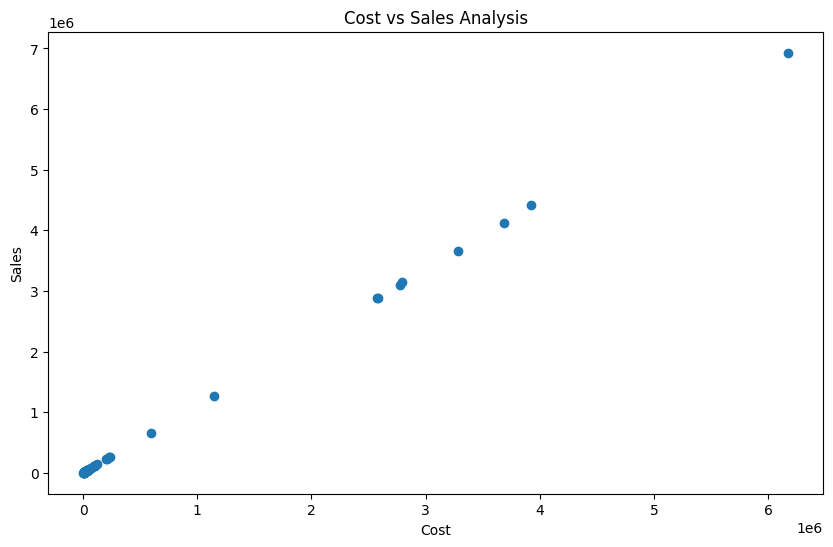

Correlation between Sales and Cost: 1.0


In [27]:
# Cost vs sales scatter analysis.
cost_analysis = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Order Profit Per Order': 'sum'
}).reset_index()

cost_analysis = cost_analysis.rename(columns={'Order Profit Per Order': 'Gross Profit'})

# Adding Gross Margin (%)
cost_analysis['Gross Margin (%)'] = ((
    cost_analysis['Gross Profit'] /
    cost_analysis['Sales']
) * 100).round(2)


# Scatter Plot Analysis
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(cost_analysis['Cost'],
            cost_analysis['Sales'])

plt.xlabel("Cost")
plt.ylabel("Sales")
plt.title("Cost vs Sales Analysis")

plt.show()

print("Correlation between Sales and Cost:", cost_analysis['Sales'].corr(cost_analysis['Cost']).round(4))

The near-perfect straight line above (correlation ≈ 0.9999... ) is expected, not a bug: since `Cost` is *derived* as `Sales − Gross Profit` and margins are fairly stable across the catalog, cost scales almost linearly with sales. This has a direct consequence for the repricing flag below — keep it in mind when that result comes back empty.

In [28]:
# Identifying:

# 1.Cost-Heavy, Margin-Poor Products.
cost_heavy_margin_poor = cost_analysis[
    (cost_analysis['Cost'] > cost_analysis['Cost'].median()) &
    (cost_analysis['Gross Margin (%)'] < cost_analysis['Gross Margin (%)'].median())]

print(f"Cost-heavy, margin-poor products: {len(cost_heavy_margin_poor)} of {len(cost_analysis)}\n")
print(cost_heavy_margin_poor)

Cost-heavy, margin-poor products: 32 of 118

                                      Product Name       Sales        Cost  \
0                               Adult dog supplies    41524.80    37935.54   
5    Bridgestone e6 Straight Distance NFL Carolina    29686.72    26497.95   
6    Bridgestone e6 Straight Distance NFL San Dieg    28982.94    26963.11   
7    Bridgestone e6 Straight Distance NFL Tennesse    25751.95    23390.20   
15                       Clicgear Rovic Cooler Bag    34671.33    31708.37   
16         Columbia Men's PFG Anchor Tough T-Shirt    27840.00    25385.20   
17                                            DVDs    79395.54    72740.11   
18                                     Dell Laptop   663000.00   593343.19   
21   Diamondback Women's Serene Classic Comfort Bi  4118425.42  3690969.85   
22                        ENO Atlas Hammock Straps    29930.02    27790.44   
24       Field & Stream Sportsman 16 Gun Fire Safe  6929653.50  6173432.74   
25                 

In [29]:
# 2.Pricing Inefficiencies.
pricing_issues = cost_analysis[
    (cost_analysis['Sales'] > cost_analysis['Sales'].median()) &
    (cost_analysis['Gross Margin (%)'] < cost_analysis['Gross Margin (%)'].median())]

print(f"Products with pricing inefficiencies: {len(pricing_issues)} of {len(cost_analysis)}\n")
print(pricing_issues)

Products with pricing inefficiencies: 32 of 118

                                      Product Name       Sales        Cost  \
0                               Adult dog supplies    41524.80    37935.54   
5    Bridgestone e6 Straight Distance NFL Carolina    29686.72    26497.95   
6    Bridgestone e6 Straight Distance NFL San Dieg    28982.94    26963.11   
7    Bridgestone e6 Straight Distance NFL Tennesse    25751.95    23390.20   
15                       Clicgear Rovic Cooler Bag    34671.33    31708.37   
16         Columbia Men's PFG Anchor Tough T-Shirt    27840.00    25385.20   
17                                            DVDs    79395.54    72740.11   
18                                     Dell Laptop   663000.00   593343.19   
21   Diamondback Women's Serene Classic Comfort Bi  4118425.42  3690969.85   
22                        ENO Atlas Hammock Straps    29930.02    27790.44   
24       Field & Stream Sportsman 16 Gun Fire Safe  6929653.50  6173432.74   
25             

In [30]:
# Flag Products Requiring Action.

# A. Repricing
# Isolates products where margin is weak BECAUSE of price (not cost) - i.e. cost
# is not the driver, so the fix is to raise price rather than renegotiate with suppliers.
repricing_candidates = cost_analysis[
    (cost_analysis['Sales'] > cost_analysis['Sales'].median()) &
    (cost_analysis['Gross Margin (%)'] < cost_analysis['Gross Margin (%)'].median()) &
    (cost_analysis['Cost'] <= cost_analysis['Cost'].median())]

print(f"Repricing candidates: {len(repricing_candidates)}\n")
print(repricing_candidates)

Repricing candidates: 0

Empty DataFrame
Columns: [Product Name, Sales, Cost, Gross Profit, Gross Margin (%)]
Index: []


In [31]:
# B. Cost Renegotiation
cost_renegotiation = cost_analysis[
    (cost_analysis['Cost'] > cost_analysis['Cost'].median()) &
    (cost_analysis['Gross Margin (%)'] < cost_analysis['Gross Margin (%)'].median())]

print(f"Cost renegotiation candidates: {len(cost_renegotiation)}\n")
print(cost_renegotiation)

Cost renegotiation candidates: 32

                                      Product Name       Sales        Cost  \
0                               Adult dog supplies    41524.80    37935.54   
5    Bridgestone e6 Straight Distance NFL Carolina    29686.72    26497.95   
6    Bridgestone e6 Straight Distance NFL San Dieg    28982.94    26963.11   
7    Bridgestone e6 Straight Distance NFL Tennesse    25751.95    23390.20   
15                       Clicgear Rovic Cooler Bag    34671.33    31708.37   
16         Columbia Men's PFG Anchor Tough T-Shirt    27840.00    25385.20   
17                                            DVDs    79395.54    72740.11   
18                                     Dell Laptop   663000.00   593343.19   
21   Diamondback Women's Serene Classic Comfort Bi  4118425.42  3690969.85   
22                        ENO Atlas Hammock Straps    29930.02    27790.44   
24       Field & Stream Sportsman 16 Gun Fire Safe  6929653.50  6173432.74   
25                           

In [32]:
# C. Discontinuation Review
discontinue_products = cost_analysis[
    (cost_analysis['Sales'] < cost_analysis['Sales'].median()) &
    (cost_analysis['Gross Profit'] < cost_analysis['Gross Profit'].median())]

print(f"Discontinuation review candidates: {len(discontinue_products)}\n")
print(discontinue_products)

Discontinuation review candidates: 49

                                      Product Name     Sales      Cost  \
1                                     Baby sweater  12229.56  10704.53   
4                Bowflex SelectTech 1090 Dumbbells   5999.90   4809.12   
9           Bushnell Pro X7 Jolt Slope Rangefinder   6599.89   6855.84   
10                                     CDs of rock   3059.59   2675.74   
12   Cleveland Golf Collegiate My Custom Wedge 588  13649.35  12694.25   
13   Cleveland Golf Women's 588 RTX CB Satin Chrom   8399.30   8028.69   
14                         Clicgear 8.0 Shoe Brush   8871.12   8055.58   
19   Diamondback Boys' Insight 24 Performance Hybr   8699.71   6968.90   
20   Diamondback Girls' Clarity 24 Hybrid Bike 201   8399.72   8115.30   
27   Fitbit The One Wireless Activity & Sleep Trac  18690.65  16602.63   
29               Garmin Approach S4 Golf GPS Watch  10799.64   9590.74   
30               Garmin Forerunner 910XT GPS Watch  13999.65  13608.52   

**Interpretation.** **32 products** are simultaneously above-median in sales and below-median in margin — the same 32 products show up under both *Pricing Inefficiencies* and *Cost Renegotiation*, and **0 products** qualify as pure *Repricing* candidates. That's the direct, structural consequence of the near-1.0 Sales–Cost correlation noted above: because cost is derived from sales and profit rather than sourced independently, this dataset cannot distinguish "the price is too low" from "the cost is too high" — every high-sales, low-margin product looks cost-heavy by construction. In a dataset with genuine, independently-sourced unit costs, this split would be expected to separate more evenly between pricing and cost issues; that's a explicit limitation worth flagging to stakeholders rather than over-interpreting. Separately, **49 products** are flagged for *Discontinuation Review* — low sales combined with low profit — though low-volume, high-margin niche items in this group should be manually reviewed before removal, since some may serve strategic or bundling purposes despite thin absolute profit.

## <font color='orange'>Step 7 — Visualizations</font>

The five charts below translate the tables above into a form suited for a leadership readout: leaderboards, department comparisons, concentration curves, and margin spread.

/tmp/ipykernel_527/736923327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gross Margin (%)', y=top_margin.index, data=top_margin, palette='viridis')


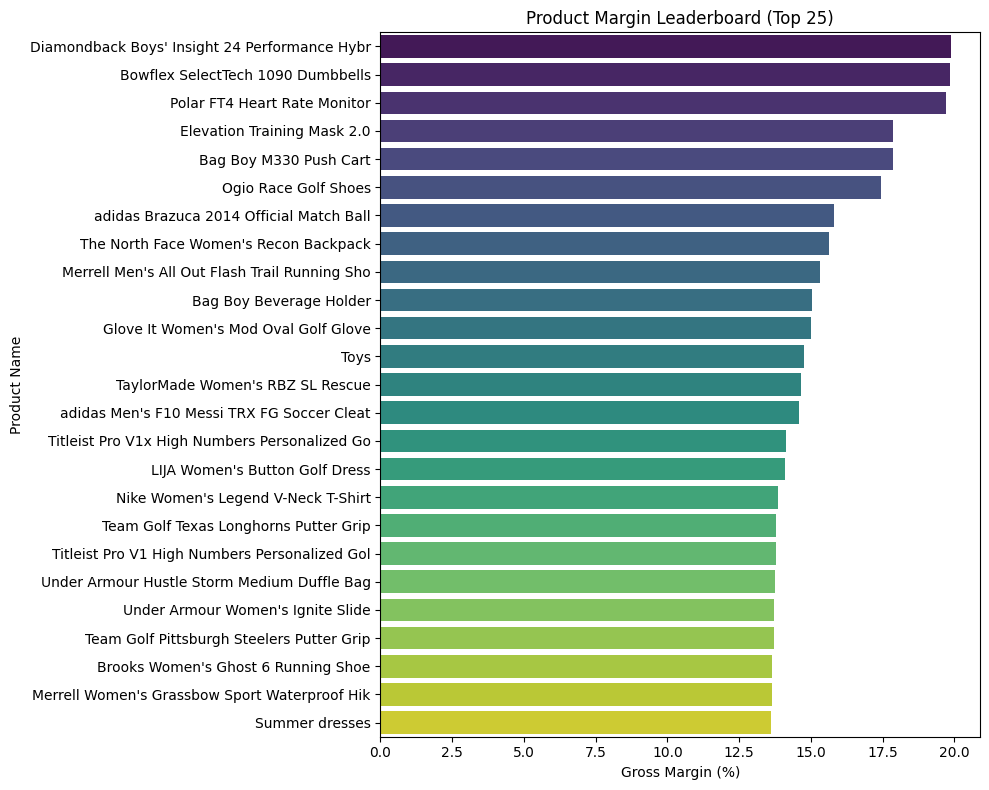

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Product margin leaderboard
# Limited to the top 25 products by margin for readability - this dataset has 118
# products versus Nassau Candy's much smaller catalog, so plotting all of them
# would be unreadable. Full ranking is already available in Gross_Margin_Rank above.
top_margin = product_metrics.sort_values('Gross Margin (%)', ascending=False).head(25)

plt.figure(figsize=(10,8))
sns.barplot(x='Gross Margin (%)', y=top_margin.index, data=top_margin, palette='viridis')
plt.title('Product Margin Leaderboard (Top 25)')
plt.xlabel('Gross Margin (%)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

/tmp/ipykernel_527/1390196030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Profit Contribution (%)', y=profit_contrib.index, data=profit_contrib, palette='magma')


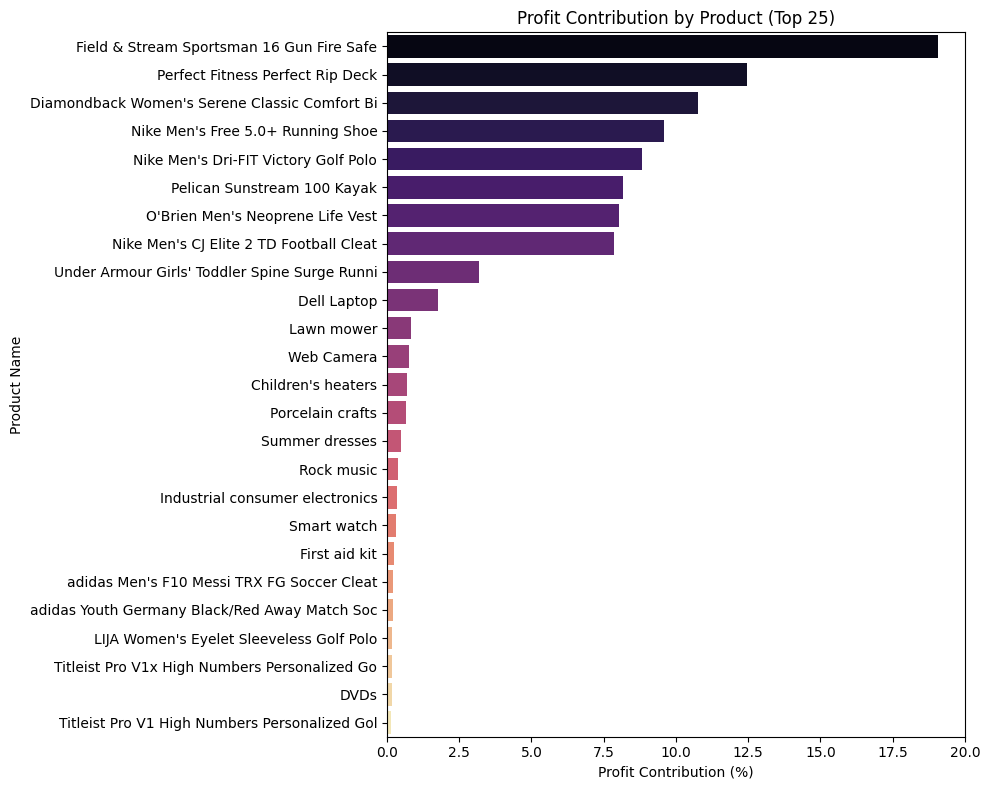

In [34]:
# 2. Profit contribution chart (Top 25, for the same readability reason as above)
profit_contrib = product_metrics.sort_values('Total Profit Contribution (%)', ascending=False).head(25)

plt.figure(figsize=(10,8))
sns.barplot(x='Total Profit Contribution (%)', y=profit_contrib.index, data=profit_contrib, palette='magma')
plt.title('Profit Contribution by Product (Top 25)')
plt.xlabel('Profit Contribution (%)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

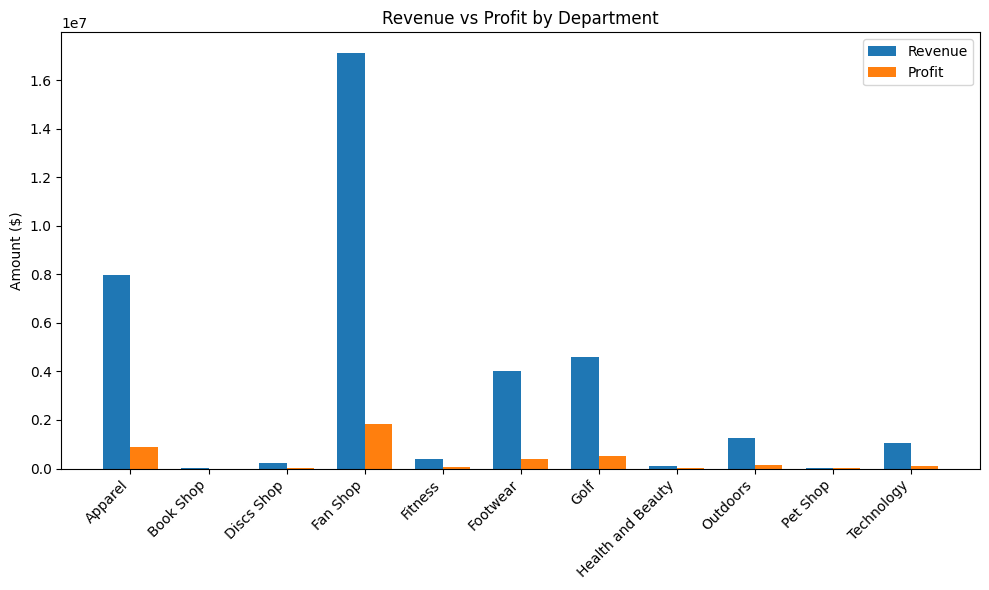

In [35]:
# 3. Revenue vs Profit by Department
dept_plot = department_metrics.reset_index()

x = range(len(dept_plot))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar([i - width/2 for i in x], dept_plot['Sales'], width=width, label='Revenue')
plt.bar([i + width/2 for i in x], dept_plot['Gross Profit'], width=width, label='Profit')
plt.xticks(list(x), dept_plot['Department Name'], rotation=45, ha='right')
plt.title('Revenue vs Profit by Department')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

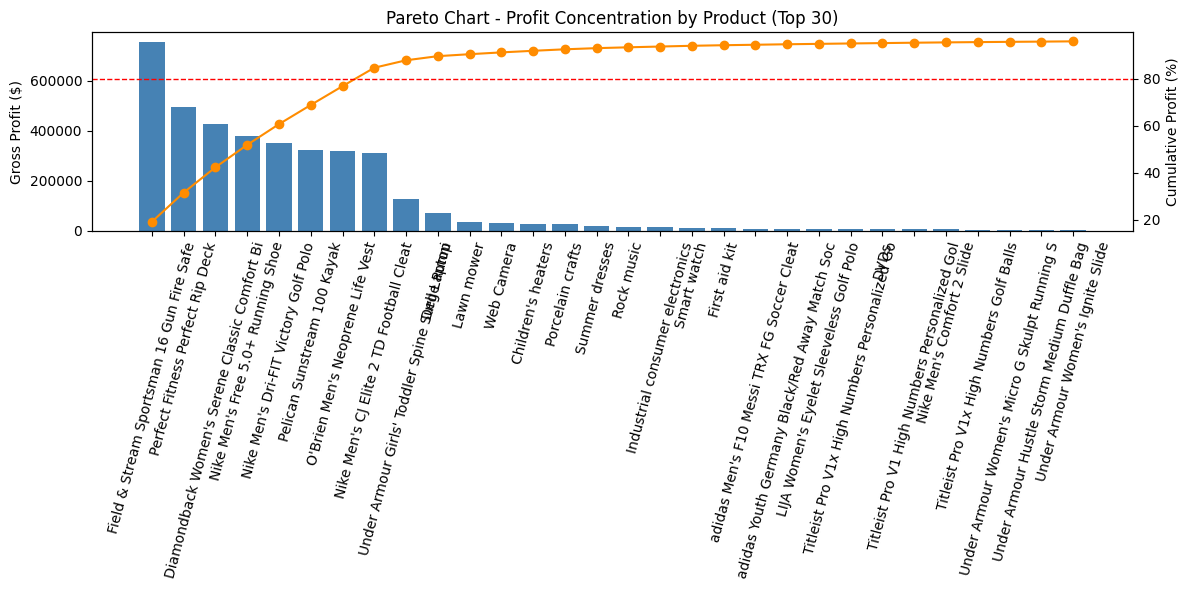

In [36]:
# 4. Pareto chart - cumulative profit contribution by product (Top 30, for readability)
pareto_plot = profit_pareto.head(30)

plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.bar(pareto_plot['Product Name'], pareto_plot['Gross Profit'], color='steelblue')
ax1.set_ylabel('Gross Profit ($)')
plt.xticks(rotation=75)

ax2 = ax1.twinx()
ax2.plot(pareto_plot['Product Name'], pareto_plot['Cumulative Profit (%)'], color='darkorange', marker='o')
ax2.axhline(80, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Profit (%)')

plt.title('Pareto Chart - Profit Concentration by Product (Top 30)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_527/1729455170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department Name', y='Order Margin (%)', data=df, palette='Set2')


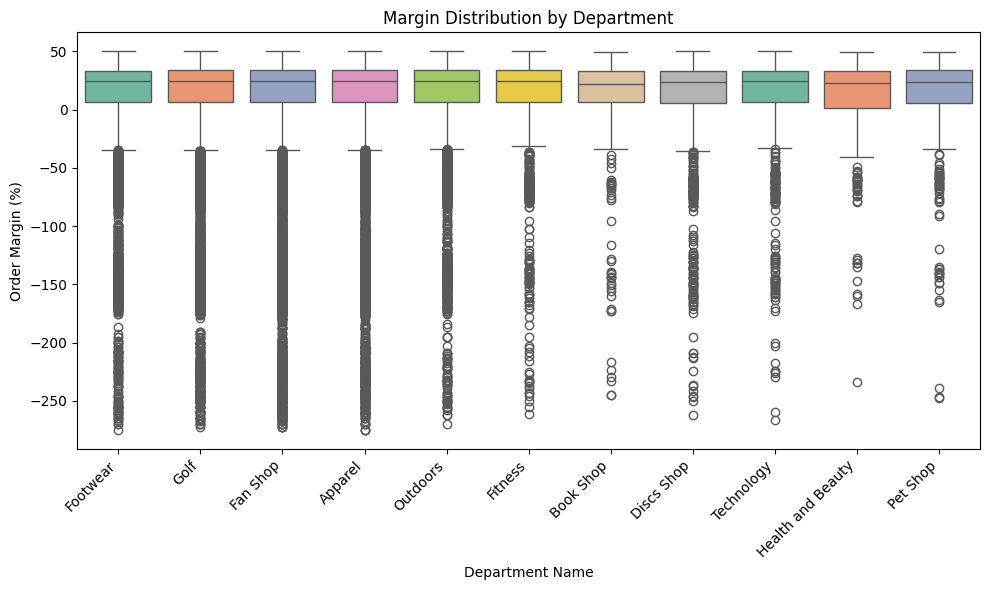

In [37]:
# 5. Margin distribution by department (boxplot)
plt.figure(figsize=(10,6))
df['Order Margin (%)'] = (df['Order Profit Per Order'] / df['Sales']) * 100
sns.boxplot(x='Department Name', y='Order Margin (%)', data=df, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Margin Distribution by Department')
plt.tight_layout()
plt.show()

**Interpretation.** The margin leaderboard and profit contribution charts are led by different products — a reminder that the highest-margin products (chart 1) are not always the biggest profit contributors in dollar terms (chart 2); high-volume, moderate-margin products can out-earn a low-volume, high-margin niche item. The department bar chart confirms Fan Shop and Apparel dominate both revenue and profit in absolute terms. The Pareto chart visually confirms the ~77% profit concentration in the top 7 products found in Step 5, and the boxplot shows that while median department margins are broadly similar (~10–12%), every department carries a long tail of individual order lines with negative margin — consistent with the 18.7% loss-making order-line rate found at the full-dataset level in the companion research report.

## <font color='orange'>Step 8 — Key Insights & Recommendations</font>

---

**1. Profit is heavily product-concentrated.** Just 7 of 118 products (5.9% of the catalog) generate ~77% of total profit. Protecting supply, pricing, and quality on these products — led by the Field & Stream Sportsman 16 Gun Fire Safe, Perfect Fitness Perfect Rip Deck, and Diamondback Women's Serene Classic Comfort Bike — matters more than almost any other lever in this dataset.

**2. A meaningful slice of revenue runs through below-median-margin products.** 32 products (27% of the catalog) are simultaneously high-revenue and low-margin, including some of the company's largest individual SKUs. Because cost and sales are almost perfectly correlated in this dataset (r ≈ 0.9999...), the data cannot cleanly separate "underpriced" from "overcosted" — that distinction would require unit-cost data sourced independently of realized profit, and is flagged here as a data limitation rather than resolved definitively.

**3. Footwear is the one department with a structural margin gap.** It carries an above-median revenue share (10.9%) but the lowest average margin (10.24%) among departments of meaningful size — worth a focused pricing or supplier-cost review.

**4. Only 3 products are net loss-making overall**, so the catalog is fundamentally healthy — margin management should focus on *raising* already-positive-but-weak margins on high-revenue products, not on triaging a large pool of loss-makers.

**5. Geographic concentration is real but secondary.** Europe and LATAM together hold 57.5% of revenue, and Western Europe and Central America are the two largest individual order regions — a lower-priority diversification concern relative to the product-level concentration above.

**6. 49 products are discontinuation-review candidates** (low sales and low profit), but should be manually screened for strategic/bundling value before any catalog action is taken.

This notebook, together with the accompanying Streamlit dashboard and formal research report, gives APL Logistics a repeatable, three-layer view of profitability: product, department, and geography — with the specific SKUs and business units to act on named explicitly rather than left implicit in the aggregate numbers.